In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import cross_validate
from scipy.optimize import minimize

%matplotlib inline
import matplotlib.pyplot as plt

First read in the preprocessed data

In [3]:
df = pd.read_csv("data/ConcreteData_cleaned.csv")
y = df['Concrete compressive strength']
X_test_norm = pd.read_csv("data/X_test_normalized.csv",index_col='Unnamed: 0')
X_train_norm = pd.read_csv("data/X_train_normalized.csv",index_col='Unnamed: 0')
y_train = y[X_train_norm.index]
y_test = y[X_test_norm.index]

Define a function to add the features originally explored in the EDA step

In [4]:
def add_engineered_features(df):
    #For ingredients that are commonly 0, create feature that is 1 if the mixture contains any and 0 if not
    df['contains_BlastFurnaceSlag'] = (df['Blast Furnace Slag'] != 0)*1
    df['contains_FlyAsh'] = (df['Fly Ash'] != 0)*1
    df['contains_Superplasticizer'] = (df['Superplasticizer'] != 0)*1

    #Some ratios
    df['w_c_ratio'] = df['Water']/df['Cement']
    df['w_binder_ratio'] = df['Water']/(df['Cement']+df['Fly Ash']+df['Blast Furnace Slag'])
    df['sp_binder_ratio'] = df['Superplasticizer']/(df['Cement']+df['Fly Ash']+df['Blast Furnace Slag'])
    df['fa_binder_ratio'] = df['Fly Ash']/(df['Cement']+df['Fly Ash']+df['Blast Furnace Slag'])
    df['bfs_binder_ratio'] = df['Blast Furnace Slag']/(df['Cement']+df['Fly Ash']+df['Blast Furnace Slag'])
    df['bfs_fa_binder_ratio'] = (df['Blast Furnace Slag']+df['Fly Ash'])/(df['Cement']+df['Fly Ash']+df['Blast Furnace Slag'])

    return df

In [5]:
X_train_norm = add_engineered_features(X_train_norm)
X_test_norm = add_engineered_features(X_test_norm)

# Linear Regression Model

In [6]:
LRmodel = LinearRegression()

scoring = ['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error']
cv_results = cross_validate(LRmodel,X_train_norm,y_train,cv=5,scoring=scoring)

In [7]:
print(f"training set r2 = {cv_results['test_r2'].mean()}")
print(f"training set MAE = {-cv_results['test_neg_mean_absolute_error'].mean()}")
print(f"training set RMSE = {-cv_results['test_neg_root_mean_squared_error'].mean()}")

training set r2 = 0.6305653684300817
training set MAE = 7.813417852199183
training set RMSE = 9.929524662592758


In [8]:
LRmodel.fit(X_train_norm,y_train)
pred = LRmodel.predict(X_test_norm)
r2_test = r2_score(y_test,pred)
mae_test = mean_absolute_error(y_test,pred)
rmse_test = root_mean_squared_error(y_test,pred)

In [9]:
print(f"test set r2 = {r2_test}")
print(f"test set MAE = {mae_test}")
print(f"test set RMSE = {rmse_test}")

test set r2 = 0.6563160150765746
test set MAE = 7.42354875532824
test set RMSE = 9.254131905918571


Try with the min-max scaled version of the data....

In [10]:
X_test_scaled = pd.read_csv("data/X_test_scaled.csv",index_col='Unnamed: 0')
X_train_scaled = pd.read_csv("data/X_train_scaled.csv",index_col='Unnamed: 0')

X_test_scaled = add_engineered_features(X_test_scaled)
X_train_scaled = add_engineered_features(X_train_scaled)

In [11]:
cv_results = cross_validate(LRmodel,X_train_scaled,y_train,cv=5,scoring=scoring)

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Adam\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Adam\anaconda3\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Adam\anaconda3\Lib\site-packages\sklearn\linear_model\_base.py", line 618, in fit
    X, y = validate_data(
           ^^^^^^^^^^^^^^
  File "c:\Users\Adam\anaconda3\Lib\site-packages\sklearn\utils\validation.py", line 2971, in validate_data
    X, y = check_X_y(X, y, **check_params)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Adam\anaconda3\Lib\site-packages\sklearn\utils\validation.py", line 1368, in check_X_y
    X = check_array(
        ^^^^^^^^^^^^
  File "c:\Users\Adam\anaconda3\Lib\site-packages\sklearn\utils\validation.py", line 1105, in check_array
    _assert_all_finite(
  File "c:\Users\Adam\anaconda3\Lib\site-packages\sklearn\utils\validation.py", line 120, in _assert_all_finite
    _assert_all_finite_element_wise(
  File "c:\Users\Adam\anaconda3\Lib\site-packages\sklearn\utils\validation.py", line 169, in _assert_all_finite_element_wise
    raise ValueError(msg_err)
ValueError: Input X contains infinity or a value too large for dtype('float64').


We get errors because some rows have infinite values from divide-by-zero errors. Let's just stick with the normalized data set for now...

In [12]:
X_train_scaled[X_train_scaled['Cement']==0]

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,contains_BlastFurnaceSlag,contains_FlyAsh,contains_Superplasticizer,w_c_ratio,w_binder_ratio,sp_binder_ratio,fa_binder_ratio,bfs_binder_ratio,bfs_fa_binder_ratio
635,0.0,0.42571,0.0,0.560878,0.0,0.25,0.873056,0.011050,1,0,0,inf,1.317514,0.0,0.0,1.0,1.0
638,0.0,0.42571,0.0,0.560878,0.0,0.25,0.873056,0.069061,1,0,0,inf,1.317514,0.0,0.0,1.0,1.0


# Random Forest Model

To limit total number of fits, we will do an initital grid search for one hyper-parameter, n_estimators

In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

RFmodel = RandomForestRegressor(random_state=10)

param_grid = {'n_estimators': np.arange(50,550,50)}

grid_search = GridSearchCV(RFmodel, cv=5, scoring='neg_mean_absolute_error', verbose=1, param_grid=param_grid)

grid_search.fit(X_train_norm,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,RandomForestR...ndom_state=10)
,param_grid,"{'n_estimators': array([ 50, 1...00, 450, 500])}"
,scoring,'neg_mean_absolute_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,250


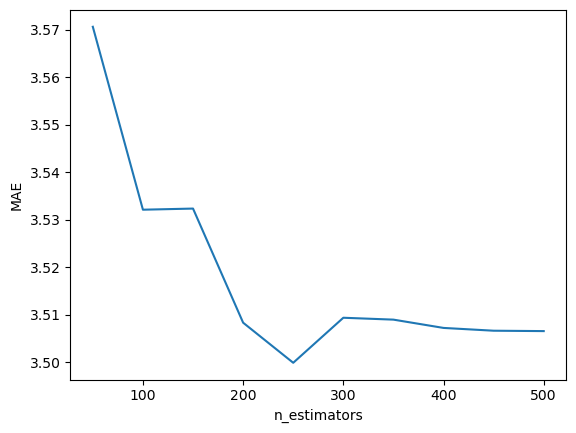

In [18]:
plt.plot(np.arange(50,550,50),-grid_search.cv_results_['mean_test_score'])
plt.xlabel("n_estimators")
plt.ylabel("MAE")
plt.show()

In general, the more trees the better but the improvement isn't that strong. Here, the smallest error actually came from a model with 250 trees

Now another grid search for the other hyper-parameters

In [19]:
param_grid = {'n_estimators': [250],
              'max_depth': [None, 5, 10],
              'min_samples_split': [2, 0.01, 0.05, 0.1],
              'min_samples_leaf': [1, 2, 5, 10, 100]}

grid_search = GridSearchCV(RFmodel, cv=5, scoring='neg_mean_absolute_error', verbose=1, param_grid=param_grid)

grid_search.fit(X_train_norm,y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,estimator,RandomForestR...ndom_state=10)
,param_grid,"{'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 0.01, ...], 'n_estimators': [250]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,250


In [20]:
grid_search.best_params_

{'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 250}

These are the defaults for the rest of the hyper-parameters

In [21]:
RFmodel = RandomForestRegressor(n_estimators=250)
cv_results = cross_validate(RFmodel,X_train_norm,y_train,cv=5,scoring=scoring)

In [22]:
print(f"training set r2 = {cv_results['test_r2'].mean()}")
print(f"training set MAE = {-cv_results['test_neg_mean_absolute_error'].mean()}")
print(f"training set RMSE = {-cv_results['test_neg_root_mean_squared_error'].mean()}")

training set r2 = 0.901207491552233
training set MAE = 3.5007783887678317
training set RMSE = 5.1214642585042345


In [23]:
RFmodel.fit(X_train_norm,y_train)
pred = RFmodel.predict(X_test_norm)
r2_test = r2_score(y_test,pred)
mae_test = mean_absolute_error(y_test,pred)
rmse_test = root_mean_squared_error(y_test,pred)

In [24]:
print(f"test set r2 = {r2_test}")
print(f"test set MAE = {mae_test}")
print(f"test set RMSE = {rmse_test}")

test set r2 = 0.917838416479315
test set MAE = 3.322290900661435
test set RMSE = 4.524706759433548


The results are much better for the random forest model. The error in the test predictions is actually slightly lower than that of the training set.

# Gradient Boosting Model

In [25]:
from sklearn.ensemble import GradientBoostingRegressor

In [27]:
GBmodel = GradientBoostingRegressor(random_state=10)

param_grid = {'n_estimators': np.arange(50,550,50),
              'learning_rate': [0.1, 0.2, 0.5, 0.7, 1.0]}

grid_search = GridSearchCV(GBmodel, cv=5, scoring='neg_mean_absolute_error', verbose=1, param_grid=param_grid)

grid_search.fit(X_train_norm,y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,estimator,GradientBoost...ndom_state=10)
,param_grid,"{'learning_rate': [0.1, 0.2, ...], 'n_estimators': array([ 50, 1...00, 450, 500])}"
,scoring,'neg_mean_absolute_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [28]:
grid_search.best_params_

{'learning_rate': 0.2, 'n_estimators': 500}

In [29]:
GBmodel = GradientBoostingRegressor(n_estimators=500, learning_rate=0.2)

In [30]:
cv_results = cross_validate(GBmodel,X_train_norm,y_train,cv=5,scoring=scoring)

In [31]:
print(f"training set r2 = {cv_results['test_r2'].mean()}")
print(f"training set MAE = {-cv_results['test_neg_mean_absolute_error'].mean()}")
print(f"training set RMSE = {-cv_results['test_neg_root_mean_squared_error'].mean()}")

training set r2 = 0.9255126582164314
training set MAE = 2.878232988234104
training set RMSE = 4.439862323511365


In [32]:
GBmodel.fit(X_train_norm,y_train)
pred = GBmodel.predict(X_test_norm)
r2_test = r2_score(y_test,pred)
mae_test = mean_absolute_error(y_test,pred)
rmse_test = root_mean_squared_error(y_test,pred)

In [33]:
print(f"test set r2 = {r2_test}")
print(f"test set MAE = {mae_test}")
print(f"test set RMSE = {rmse_test}")

test set r2 = 0.9270299243260994
test set MAE = 2.8121838205281664
test set RMSE = 4.264110360279138


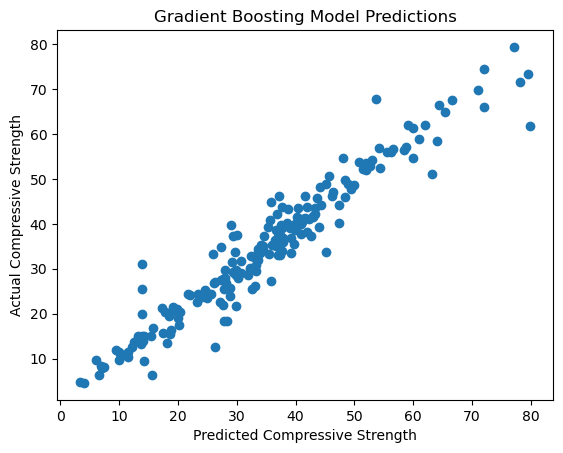

In [34]:
plt.scatter(pred,y_test)
plt.xlabel("Predicted Compressive Strength")
plt.ylabel("Actual Compressive Strength")
plt.title("Gradient Boosting Model Predictions")
plt.show()

The gradient boosting model edges out the random forest model in terms of all three of the metrics investigated here. We will consider this the winning model!

# Maximizing the target variable:
I want to use the best model to predict what set of input variables (concrete components) result in the strongest concrete.
First we will need an objective function to maximize (here we will take the negative and minimize it). The objective function is essentially the output of the gradient boosting model.

In [35]:
def objective_func(x):
    df_X = pd.DataFrame(x).T
    return -GBmodel.predict(df_X)

Now we need a set of input values to initialize our minimization scheme. We'll choose the average of the input variables for the five highest results from the test set and call it x0

In [36]:
x0 = X_test_norm.loc[y_test.nlargest(5).index].mean().values

In [37]:
pd.DataFrame(x0).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,0.179304,0.060319,0.0,0.067633,0.006208,0.389518,0.297018,0.134807,0.8,0.0,1.0,0.379555,0.281991,0.026009,0.0,0.245528,0.245528


Our minimization has bounds and constraints on some of the variables so we have to set those up here. For example, the component amounts must be positive and the ratio features have to be related to the raw features accordingly.

In [38]:
bnds = [(0,None),(0,None),(0,None),(0,None),(0,None),(0,None),(0,None),(0,None),(0,1),(0,1),(0,1),(0,None),(0,None),(0,None),(0,None),(0,None),(0,None)]

con_w_c = {'type': 'eq', 'fun': lambda x: x[3]/x[0] - x[11]}
con_w_bind = {'type': 'eq', 'fun': lambda x: x[3]/(x[0]+x[1]+x[2])- x[12]}
con_sp_bind = {'type': 'eq', 'fun': lambda x: x[4]/(x[0]+x[1]+x[2]) - x[13]}
con_fa_bind = {'type': 'eq', 'fun': lambda x: x[2]/(x[0]+x[1]+x[2]) - x[14]}
con_bfs_bind = {'type': 'eq', 'fun': lambda x: x[1]/(x[0]+x[1]+x[2]) - x[15]}
con_bfs_fa_bind = {'type': 'eq', 'fun': lambda x: (x[1]+x[2])/(x[0]+x[1]+x[2]) - x[16]}
constraints = [con_w_c, con_w_bind, con_sp_bind, con_fa_bind, con_bfs_bind, con_bfs_fa_bind]

Now we use a minimize function from scipy to perform the optimization

In [39]:
result = minimize(objective_func,x0,method='SLSQP',bounds=bnds,constraints=constraints)

c:\Users\Adam\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
c:\Users\Adam\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
c:\Users\Adam\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
c:\Users\Adam\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
c:\Users\Adam\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  

In [40]:
result.success

True

In [41]:
result.x

array([1.79793544e-01, 5.88143103e-02, 1.10401767e-04, 6.76408712e-02,
       6.20877905e-03, 3.89518335e-01, 2.97018222e-01, 1.34806630e-01,
       8.00000000e-01, 0.00000000e+00, 1.00000000e+00, 3.76214128e-01,
       2.83350224e-01, 2.60088154e-02, 4.62477269e-04, 2.46375419e-01,
       2.46837897e-01])

In [42]:
result.fun

-72.55439049286038

result.x shows the values of the optimized and normalized input variables. The optimization can not constrain inputs to binary 0 or 1 so the binary features 'contains_X' may have to be estimated by whether they're closer to 0 or 1 and by the result for the amount of the corresponding component from the optimization. result.fun shows the optimized value of the concrete compressive strength.

In particular for the 'Age' feature, we must 'unscale' it back so the units are useful in days. We need the original data that was used to scale it originally to do this.

In [43]:
def unscale(var,min,max):
    return var * (max-min) + min

In [44]:
df = pd.read_csv("data/ConcreteData_cleaned.csv")
#Separate features and target variable
X = df.drop(columns=["Concrete compressive strength"])
y = df["Concrete compressive strength"]
#Train/test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8, random_state=10)

In [45]:
age_orig_min = X_train['Age'].min()
age_orig_max = X_train['Age'].max()

In [46]:
unscale(result.x[7],age_orig_min,age_orig_max)

51.79999999999998

Our optimization suggests that aging the mixture concrete mixture for 52 days is optimal

Finally, let's plot some of the best and worst concrete mixtures from the data along with our optimized prediction

In [47]:
test_df = X_test_norm.copy()
test_df['Concrete compressive strength'] = y_test
test_df['Age'] = df.loc[test_df.index,'Age']
largest = test_df.nlargest(5,'Concrete compressive strength').iloc[:,:7]

In [48]:
opt_df = pd.DataFrame(result.x[:7]).T
opt_df.columns = largest.columns

In [49]:
largest_opt = pd.concat([largest,opt_df])

C:\Users\Adam\AppData\Local\Temp\ipykernel_14144\1697895511.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(np.arange(0,120,20))


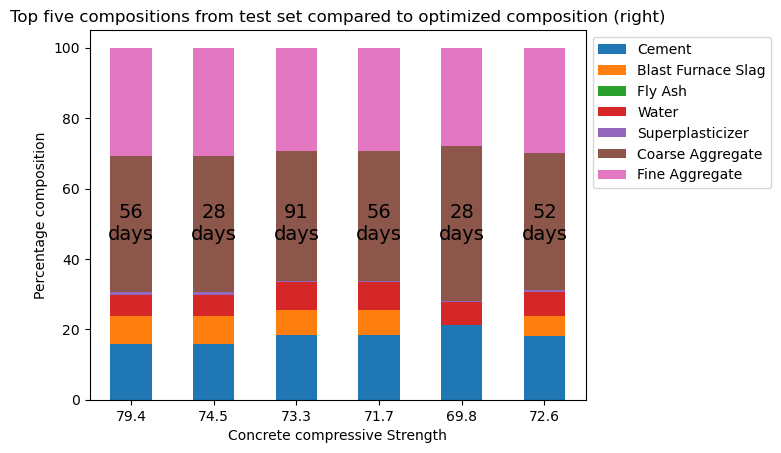

In [52]:
fig,ax = plt.subplots()
largest_opt.plot(kind='bar',stacked=True,ax=ax)
plt.legend(bbox_to_anchor=(1,1),loc='upper left')
for i in range(len(largest)):
    plt.annotate(str(test_df.loc[largest.index,'Age'].iloc[i])+'\ndays',xy=(i,0.5),fontsize=14,ha='center',va='center')
plt.annotate(str(52)+'\ndays',xy=(5,0.5),fontsize=14,ha='center',va='center')

labels = list(test_df.nlargest(5,'Concrete compressive strength').loc[:,'Concrete compressive strength'].round(1))
labels.append(np.round(-result.fun,1))
ax.set_xticklabels(labels,rotation='horizontal')
ax.set_xlabel("Concrete compressive Strength")
ax.set_title("Top five compositions from test set compared to optimized composition (right)")
ax.set_ylabel("Percentage composition")
ax.set_yticklabels(np.arange(0,120,20))

plt.show()

In [53]:
smallest = test_df.nsmallest(5,'Concrete compressive strength').iloc[:,:7]
smallest_opt = pd.concat([smallest,opt_df])

C:\Users\Adam\AppData\Local\Temp\ipykernel_14144\4189850145.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(np.arange(0,120,20))


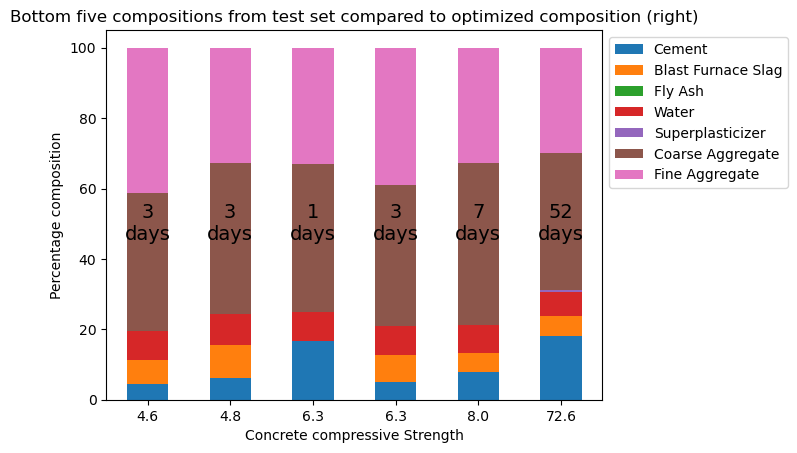

In [54]:
fig,ax = plt.subplots()
smallest_opt.plot(kind='bar',stacked=True,ax=ax)
plt.legend(bbox_to_anchor=(1,1),loc='upper left')
for i in range(len(smallest)):
    plt.annotate(str(test_df.loc[smallest.index,'Age'].iloc[i])+'\ndays',xy=(i,0.5),fontsize=14,ha='center',va='center')
plt.annotate(str(52)+'\ndays',xy=(5,0.5),fontsize=14,ha='center',va='center')

labels = list(test_df.nsmallest(5,'Concrete compressive strength').loc[:,'Concrete compressive strength'].round(1))
labels.append(np.round(-result.fun,1))
ax.set_xticklabels(labels,rotation='horizontal')
ax.set_xlabel("Concrete compressive Strength")
ax.set_title("Bottom five compositions from test set compared to optimized composition (right)")
ax.set_ylabel("Percentage composition")
ax.set_yticklabels(np.arange(0,120,20))

plt.show()

The most apparent conclusion is that significant aging time is very important. All of the low strength concrete mixtures sampled here have very low aging times (less than 10 days). Let's take one last look at this aspect of the data. Below we plot the ideal range of aging time on the x-axis with compressive strength on the y-axis. The color gradient corresponds with the water to cement ratio. We see the strongest mixtures in this range with a water:cement ratio around 0.4.

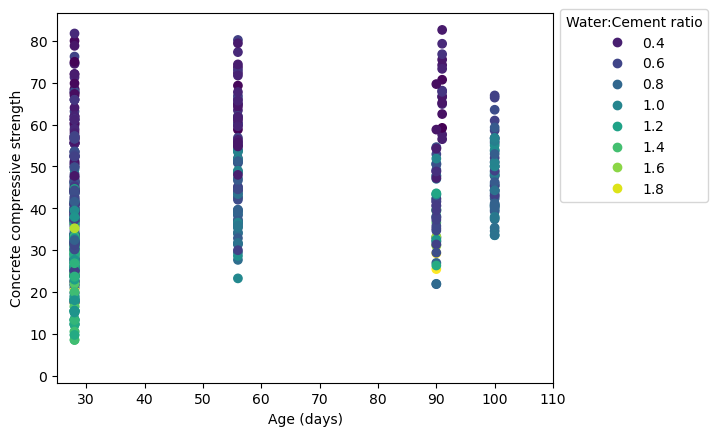

In [76]:
fig, ax = plt.subplots()
scatter = ax.scatter(x=df['Age'],y=df['Concrete compressive strength'],c=df['Water']/df['Cement'])
plt.xlim(25,110)
plt.xlabel("Age (days)")
plt.ylabel("Concrete compressive strength")
# Get handles and labels automatically from the scatter object
handles, labels = scatter.legend_elements()

# Add the legend using the generated handles and labels
ax.legend(handles, labels, loc="center left", title="Water:Cement ratio", bbox_to_anchor=(1,0.75))
plt.show()